<a href="https://colab.research.google.com/github/Samarjamal326/Flyrank/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-11 — Capstone Research Paper

**Lane:** CTR / Engagement Opportunity Scoring

**Research question:** Can a leakage-safe model prioritize measured content items for search-engagement review better than a transparent Week-4 rule?

This notebook assembles the validated model, baseline, results, limitations, ranked recommendations, and paper-ready exports.

**Claim standard:** observed, measured, directional, decision-support.

This work does **not** claim that refreshing content causes higher CTR or rankings.

## 1. Question

### Problem statement

Content teams can have more pages worth investigating than they can review at once. This project asks whether measured search-performance signals can prioritize that review queue.

### Outcome

The future outcome is a benchmark-relative proxy:

> `1` = March 2026 CTR was below the February position-tier CTR benchmark learned from training clients.

This is a prioritization proxy, not a causal intervention label.

In [15]:
%pip -q install duckdb huggingface_hub pandas numpy scikit-learn matplotlib

import os
import subprocess
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

repo_dir = "/content/Flyrank"
repo_url = "https://github.com/Samarjamal326/Flyrank.git"

if not os.path.exists(repo_dir):
    subprocess.run(["git", "clone", repo_url, repo_dir], check=True)

os.chdir(repo_dir)

for folder in ["work/outputs", "work/figures", "work/paper", "submission"]:
    Path(folder).mkdir(parents=True, exist_ok=True)

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    raise RuntimeError("HF_TOKEN is missing. Add it in Colab Secrets as HF_TOKEN with Notebook access ON.")

con = duckdb.connect()
con.execute("SET enable_progress_bar = false")
con.execute("SET VARIABLE hf_token = ?", [HF_TOKEN])
con.execute(
    "CREATE OR REPLACE SECRET hf "
    "(TYPE huggingface, TOKEN getvariable('hf_token'))"
)

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT = f"{REL}/fact_content_daily_performance"

FEB = f"read_parquet('{FACT}/month=2026-02/*.parquet')"
MAR = f"read_parquet('{FACT}/month=2026-03/*.parquet')"

print("Ready.")

Ready.


## 2. Data

The paper uses the FlyRank internship warehouse.

**Tables used**

- `fact_content_daily_performance` — February and March 2026 daily performance.
- `dim_content` — content creation date for descriptive age analysis when needed.

**Windows**

- Decision/features: February 2026.
- Future observed outcome: March 2026.

**Exclusions**

Rows without measured GSC data are excluded from measured aggregates. March outcomes require at least 100 impressions to avoid extremely noisy CTR denominators.

The public paper must not contain client names, domains, URLs, raw queries, titles, or credentials. Pseudonymous IDs are used only inside the reproducible notebook for joins and grouping.

In [16]:
feb_sql = f"""
WITH feb AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) FILTER (WHERE gsc_data_available IS TRUE) AS feb_impressions,
        SUM(gsc_clicks) FILTER (WHERE gsc_data_available IS TRUE) AS feb_clicks,
        SUM(gsc_sum_position) FILTER (WHERE gsc_data_available IS TRUE) AS feb_sum_position,
        COUNT(*) FILTER (WHERE gsc_data_available IS TRUE) AS feb_measured_days
    FROM {FEB}
    GROUP BY 1, 2
)
SELECT
    client_hash_id,
    content_hash_id,
    feb_impressions,
    feb_clicks,
    feb_clicks / NULLIF(feb_impressions, 0) AS feb_ctr,
    feb_sum_position / NULLIF(feb_impressions, 0) AS feb_avg_position,
    feb_measured_days,
    CASE
        WHEN feb_sum_position / NULLIF(feb_impressions, 0) <= 3 THEN 'top_3'
        WHEN feb_sum_position / NULLIF(feb_impressions, 0) <= 10 THEN 'page_1'
        WHEN feb_sum_position / NULLIF(feb_impressions, 0) <= 20 THEN 'striking'
        WHEN feb_sum_position / NULLIF(feb_impressions, 0) <= 50 THEN 'page_3_5'
        ELSE 'deep'
    END AS position_tier
FROM feb
WHERE feb_measured_days > 0
  AND feb_impressions > 0
  AND feb_sum_position IS NOT NULL
"""

mar_sql = f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) FILTER (WHERE gsc_data_available IS TRUE) AS mar_impressions,
    SUM(gsc_clicks) FILTER (WHERE gsc_data_available IS TRUE) AS mar_clicks,
    COUNT(*) FILTER (WHERE gsc_data_available IS TRUE) AS mar_measured_days
FROM {MAR}
GROUP BY 1, 2
"""

feb = con.sql(feb_sql).df()
mar = con.sql(mar_sql).df()

data = feb.merge(
    mar,
    on=["client_hash_id", "content_hash_id"],
    how="inner",
    validate="one_to_one"
)

data["future_ctr"] = data["mar_clicks"] / data["mar_impressions"]

data = data[
    data["mar_measured_days"].gt(0)
    & data["mar_impressions"].ge(100)
    & data["future_ctr"].notna()
].copy()

print(f"Eligible rows: {len(data):,}")
print(f"Unique clients: {data.client_hash_id.nunique():,}")

Eligible rows: 86,560
Unique clients: 37


## 3. Methodology

**Features:** February impressions, clicks, CTR, and impression-weighted average position.

**Baseline:** positive CTR gap to the training position-tier median multiplied by `log(1 + impressions)`.

**Model:** standardized Logistic Regression. It is intentionally interpretable; complexity is not rewarded by itself.

**Validation:** client-grouped 80/20 split. No client appears in both train and test.

**Leakage control:** the position-tier benchmark is learned from training clients only and then frozen. March outcome fields and label-derived fields are not model features.

In [17]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(data, groups=data["client_hash_id"]))

train = data.iloc[train_idx].copy()
test = data.iloc[test_idx].copy()

assert set(train.client_hash_id).isdisjoint(set(test.client_hash_id))

tier_benchmark = (
    train.groupby("position_tier", observed=True)["feb_ctr"]
    .median()
    .rename("tier_median_ctr")
)

train = train.merge(tier_benchmark, on="position_tier", how="left", validate="many_to_one")
test = test.merge(tier_benchmark, on="position_tier", how="left", validate="many_to_one")

train["y"] = (train["future_ctr"] < train["tier_median_ctr"]).astype(int)
test["y"] = (test["future_ctr"] < test["tier_median_ctr"]).astype(int)

FEATURES = [
    "feb_impressions",
    "feb_clicks",
    "feb_ctr",
    "feb_avg_position",
]

model = Pipeline([
    ("scale", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

model.fit(train[FEATURES], train["y"])
test["model_score"] = model.predict_proba(test[FEATURES])[:, 1]

test["ctr_gap_pp"] = (
    test["tier_median_ctr"] - test["feb_ctr"]
).clip(lower=0)

test["baseline_score"] = (
    test["ctr_gap_pp"] * np.log1p(test["feb_impressions"])
)

print("Train clients:", train.client_hash_id.nunique())
print("Test clients:", test.client_hash_id.nunique())
print("Train rows:", len(train))
print("Test rows:", len(test))

Train clients: 29
Test clients: 8
Train rows: 75670
Test rows: 10890


## 4. Results — model vs baseline

Both approaches are evaluated on the **same client-held-out test set** and the same benchmark-relative target.

Primary metric: **Precision@10**, because the intended use is prioritizing a small human review queue.

Supporting metrics: Precision@50, Average Precision, ROC-AUC, and the positive-label base rate.

In [18]:
def precision_at_k(y_true, scores, k):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    k = min(k, len(y_true))
    order = np.argsort(-scores)[:k]
    return float(y_true[order].mean())

def evaluate(scores):
    return {
        "Precision@10": precision_at_k(test["y"], scores, 10),
        "Precision@50": precision_at_k(test["y"], scores, 50),
        "Average Precision": float(average_precision_score(test["y"], scores)),
        "ROC-AUC": float(roc_auc_score(test["y"], scores)),
    }

comparison = pd.DataFrame({
    "Model": evaluate(test["model_score"]),
    "Week-4 baseline": evaluate(test["baseline_score"]),
}).T

comparison["Base rate"] = float(test["y"].mean())
display(comparison.round(4))

print(
    "Observed Precision@10 difference:",
    f"{comparison.loc['Model', 'Precision@10'] - comparison.loc['Week-4 baseline', 'Precision@10']:+.4f}"
)

,Precision@10,Precision@50,Average Precision,ROC-AUC,Base rate
Model,0.7,0.76,0.5706,0.8193,0.2905
Week-4 baseline,0.8,0.80,0.5476,0.7687,0.2905


Observed Precision@10 difference: -0.1000


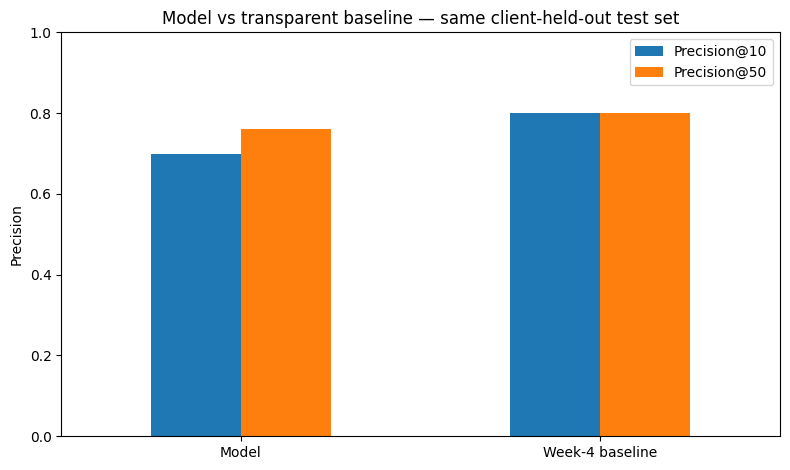

Saved: work/figures/model_vs_baseline_precision.png


In [19]:
chart_df = comparison[["Precision@10", "Precision@50"]]

ax = chart_df.plot(kind="bar", figsize=(8, 4.8))
ax.set_ylabel("Precision")
ax.set_title("Model vs transparent baseline — same client-held-out test set")
ax.set_ylim(0, 1)
ax.legend(title="")
plt.xticks(rotation=0)
plt.tight_layout()

figure_path = "work/figures/model_vs_baseline_precision.png"
plt.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

### Feature interpretation

Model coefficients are descriptive evidence about the fitted ranking signal, not causal effects.

In [20]:
coef_df = pd.DataFrame({
    "feature": FEATURES,
    "coefficient": model.named_steps["logreg"].coef_[0]
}).sort_values("coefficient", key=np.abs, ascending=False)

display(coef_df)

,feature,coefficient
1,feb_clicks,-7.210524
3,feb_avg_position,-3.637795
0,feb_impressions,1.920920
2,feb_ctr,-0.359915


## 5. Limitations & honest framing

- The target is a benchmark-relative proxy, not a direct label for intervention success.
- The study covers one February → March 2026 observation window.
- Client-grouped validation improves the honesty of the estimate but does not prove future generalization.
- CTR is observational and related to position and impression volume.
- Low-volume CTR estimates are noisy.
- The analysis does not estimate causal lift from refreshing, rewriting, redirecting, or deleting content.
- The public paper must not expose private queries, URLs, domains, client identities, or credentials.

### Claim rewrite

**Too strong:** “The model identifies pages that should be refreshed.”

**Evidence-safe:** “On this client-held-out slice, the model ranks content items for review using a measured benchmark-relative CTR signal.”

**Too strong:** “Refreshing older pages improves CTR.”

**Evidence-safe:** “The age analysis can surface directional patterns for review; it does not establish that refreshing older content causes CTR improvement.”

## 6. Ranked recommendations

1. **Prioritize CTR review** — high model score with sufficient measured volume.
2. **Review if capacity allows** — moderate score with adequate evidence.
3. **Monitor / do not prioritize** — weak score or insufficient evidence.

### Human-review rules

Confirm measured volume and position context, inspect the available page/query context, consider recent edits and seasonality, and record the final action separately from the model score.

### Do not automate

Do not automatically rewrite or publish content, delete/redirect/deindex pages, claim ranking or CTR gains, or treat the score as causal advice.

## 7. Reproducibility

The final repository should contain the weekly notebooks and this capstone notebook under `work/notebooks/`.

The notebook accesses the gated warehouse through the Colab `HF_TOKEN` Secret. No credential is stored in the repository.

The paper's metrics and chart are regenerated by this notebook.

## 8. Acknowledgments & data credit

**Built on the FlyRank ML Internship dataset.**

Data source: [FlyRank](https://flyrank.ai)

Credit is included as standard research practice.

## 9. Publication-grade figures, architecture, and analysis

The final paper is deliberately more detailed than the weekly notebooks. It includes:

- an end-to-end data/model architecture diagram;
- a leakage-safe validation diagram;
- data-contract and split tables;
- descriptive CTR-by-position results;
- model-vs-baseline precision results;
- score-distribution and coefficient plots;
- error-analysis examples using pseudonymous IDs only;
- content-age / refresh context;
- a ranked action playbook;
- explicit limitations, no-go decisions, and reproducibility notes.

All measured numbers below are regenerated from the warehouse when this notebook runs.

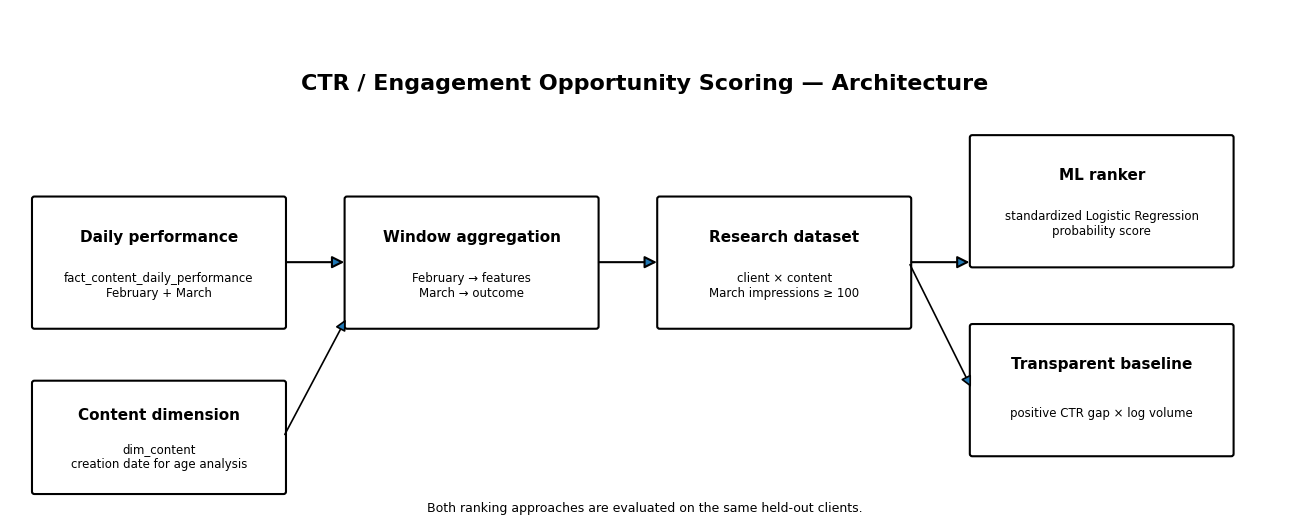

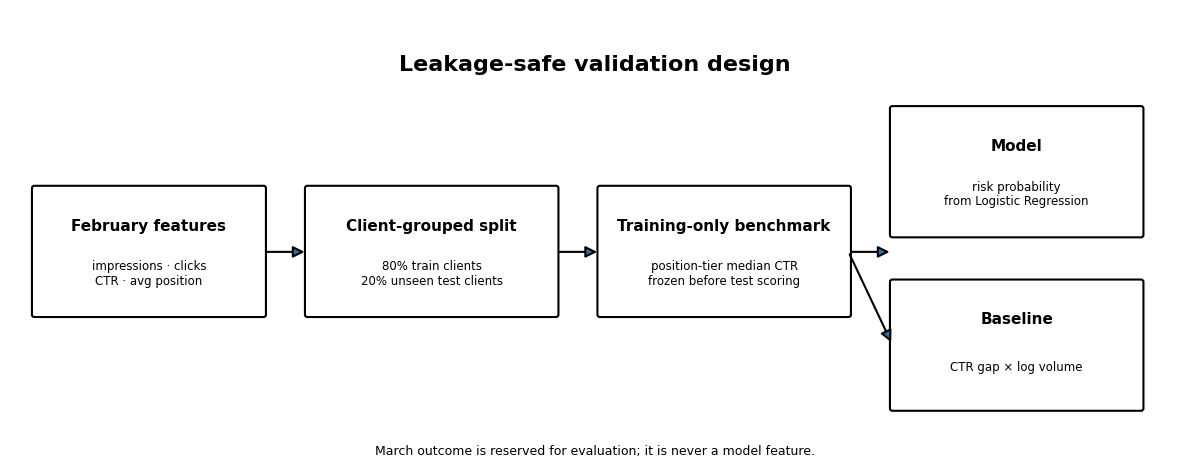

In [21]:
from pathlib import Path
import base64, json, html

Path("work/figures").mkdir(parents=True, exist_ok=True)
Path("work/outputs").mkdir(parents=True, exist_ok=True)
Path("docs").mkdir(parents=True, exist_ok=True)

def save_box(ax, x, y, w, h, title, body):
    from matplotlib.patches import FancyBboxPatch
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.025",
                         linewidth=1.5, fill=False)
    ax.add_patch(box)
    ax.text(x+w/2, y+h*0.70, title, ha="center", va="center",
            fontsize=11, fontweight="bold")
    ax.text(x+w/2, y+h*0.32, body, ha="center", va="center",
            fontsize=8.5, wrap=True)

# Figure A — architecture
fig, ax = plt.subplots(figsize=(13, 5.4))
ax.set_xlim(0, 13); ax.set_ylim(0, 5.4); ax.axis("off")
save_box(ax, .25, 2.05, 2.55, 1.35, "Daily performance",
         "fact_content_daily_performance\nFebruary + March")
save_box(ax, .25, .30, 2.55, 1.15, "Content dimension",
         "dim_content\ncreation date for age analysis")
save_box(ax, 3.45, 2.05, 2.55, 1.35, "Window aggregation",
         "February → features\nMarch → outcome")
save_box(ax, 6.65, 2.05, 2.55, 1.35, "Research dataset",
         "client × content\nMarch impressions ≥ 100")
save_box(ax, 9.85, 2.70, 2.65, 1.35, "ML ranker",
         "standardized Logistic Regression\nprobability score")
save_box(ax, 9.85, .70, 2.65, 1.35, "Transparent baseline",
         "positive CTR gap × log volume")
from matplotlib.patches import FancyArrowPatch
for a,b in [(2.80,3.45),(6.00,6.65),(9.20,9.85)]:
    ax.add_patch(FancyArrowPatch((a,2.73),(b,2.73),arrowstyle="-|>",
                                 mutation_scale=18,linewidth=1.5))
ax.add_patch(FancyArrowPatch((2.80,.88),(3.45,2.15),arrowstyle="-|>",
                             mutation_scale=16,linewidth=1.2))
ax.add_patch(FancyArrowPatch((9.20,2.73),(9.85,1.38),arrowstyle="-|>",
                             mutation_scale=16,linewidth=1.2))
ax.text(6.5, 4.55, "CTR / Engagement Opportunity Scoring — Architecture",
        ha="center", fontsize=16, fontweight="bold")
ax.text(6.5, .08, "Both ranking approaches are evaluated on the same held-out clients.",
        ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("work/figures/architecture_pipeline.png", dpi=220, bbox_inches="tight")
plt.show()

# Figure B — validation design
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.set_xlim(0, 12); ax.set_ylim(0, 4.8); ax.axis("off")
save_box(ax, .25, 1.55, 2.35, 1.35, "February features",
         "impressions · clicks\nCTR · avg position")
save_box(ax, 3.05, 1.55, 2.55, 1.35, "Client-grouped split",
         "80% train clients\n20% unseen test clients")
save_box(ax, 6.05, 1.55, 2.55, 1.35, "Training-only benchmark",
         "position-tier median CTR\nfrozen before test scoring")
save_box(ax, 9.05, 2.40, 2.55, 1.35, "Model",
         "risk probability\nfrom Logistic Regression")
save_box(ax, 9.05, .55, 2.55, 1.35, "Baseline",
         "CTR gap × log volume")
for a,b in [(2.60,3.05),(5.60,6.05),(8.60,9.05)]:
    ax.add_patch(FancyArrowPatch((a,2.22),(b,2.22),arrowstyle="-|>",
                                 mutation_scale=17,linewidth=1.5))
ax.add_patch(FancyArrowPatch((8.60,2.22),(9.05,1.23),arrowstyle="-|>",
                             mutation_scale=17,linewidth=1.5))
ax.text(6, 4.15, "Leakage-safe validation design",
        ha="center", fontsize=16, fontweight="bold")
ax.text(6, .05, "March outcome is reserved for evaluation; it is never a model feature.",
        ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("work/figures/methodology_validation.png", dpi=220, bbox_inches="tight")
plt.show()

### Data and split receipt

The following table makes the paper auditable at a glance. The exact counts are produced by the run rather than hardcoded.

In [22]:
data_receipt = pd.DataFrame({
    "Measure": [
        "February aggregated client-content rows",
        "March aggregated client-content rows",
        "Eligible modeling rows",
        "Unique clients",
        "Unique content items",
        "Train clients",
        "Test clients",
        "Train rows",
        "Test rows",
        "Test positive rate"
    ],
    "Value": [
        len(feb), len(mar), len(data),
        data.client_hash_id.nunique(),
        data.content_hash_id.nunique(),
        train.client_hash_id.nunique(),
        test.client_hash_id.nunique(),
        len(train), len(test),
        test.y.mean()
    ]
})
display(data_receipt)
data_receipt.to_csv("work/outputs/data_receipt.csv", index=False)

,Measure,Value
0,February aggregated client-content rows,153559.000000
1,March aggregated client-content rows,331437.000000
2,Eligible modeling rows,86560.000000
3,Unique clients,37.000000
4,Unique content items,86560.000000
5,Train clients,29.000000
6,Test clients,8.000000
7,Train rows,75670.000000
8,Test rows,10890.000000
9,Test positive rate,0.290542


## 10. Descriptive results: search CTR by position tier

Position is included because the baseline and proxy target explicitly normalize CTR expectations by position tier. The plot below is descriptive evidence about the observed February data; it is not a causal claim about rankings.

,items,impressions,clicks,median_ctr,median_position,weighted_ctr
position_tier,,,,,,
top_3,1387,1136518.0,5526.0,0.00223,2.15686,0.00486
page_1,5839,6680665.0,26724.0,0.00147,6.21063,0.00400
striking,2484,2508703.0,6462.0,0.00000,13.17960,0.00258
page_3_5,1135,1011654.0,1258.0,0.00000,26.51683,0.00124
deep,45,23055.0,17.0,0.00000,56.31633,0.00074


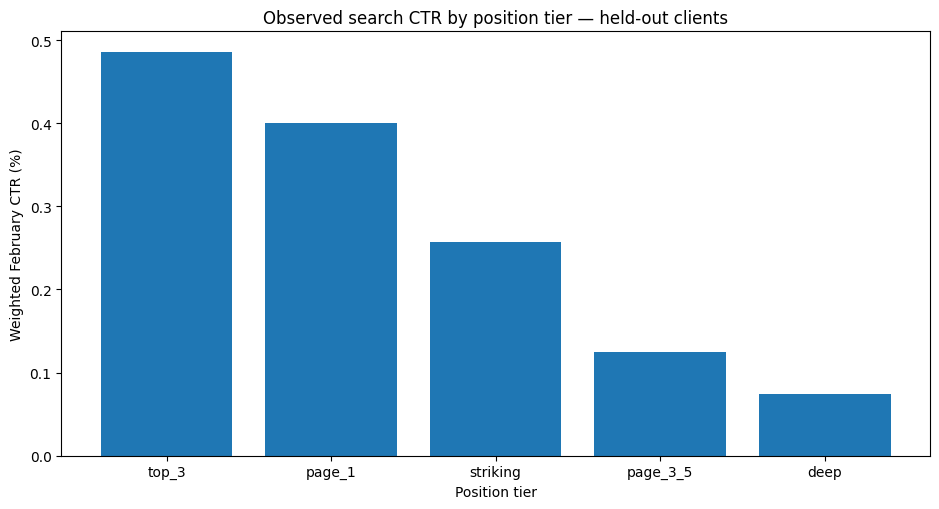

In [23]:
tier_order = ["top_3","page_1","striking","page_3_5","deep"]
tier_summary = (
    test.groupby("position_tier", observed=True)
        .agg(
            items=("content_hash_id","size"),
            impressions=("feb_impressions","sum"),
            clicks=("feb_clicks","sum"),
            median_ctr=("feb_ctr","median"),
            median_position=("feb_avg_position","median")
        )
        .reindex(tier_order)
)
tier_summary["weighted_ctr"] = tier_summary["clicks"] / tier_summary["impressions"]
display(tier_summary.round(5))

fig, ax = plt.subplots(figsize=(9.5,5.2))
p = tier_summary.dropna(subset=["weighted_ctr"])
ax.bar(p.index.astype(str), p["weighted_ctr"]*100)
ax.set_xlabel("Position tier")
ax.set_ylabel("Weighted February CTR (%)")
ax.set_title("Observed search CTR by position tier — held-out clients")
plt.tight_layout()
plt.savefig("work/figures/ctr_by_position_tier.png", dpi=220, bbox_inches="tight")
plt.show()

## 11. Model vs baseline — primary result

Both approaches are scored on the **same client-held-out test set**. Precision@10 is the primary metric because the intended decision is a small review queue.

,Precision@10,Precision@50,Average Precision,ROC-AUC,Base rate
Model,0.7,0.76,0.5706,0.8193,0.2905
Week-4 baseline,0.8,0.80,0.5476,0.7687,0.2905


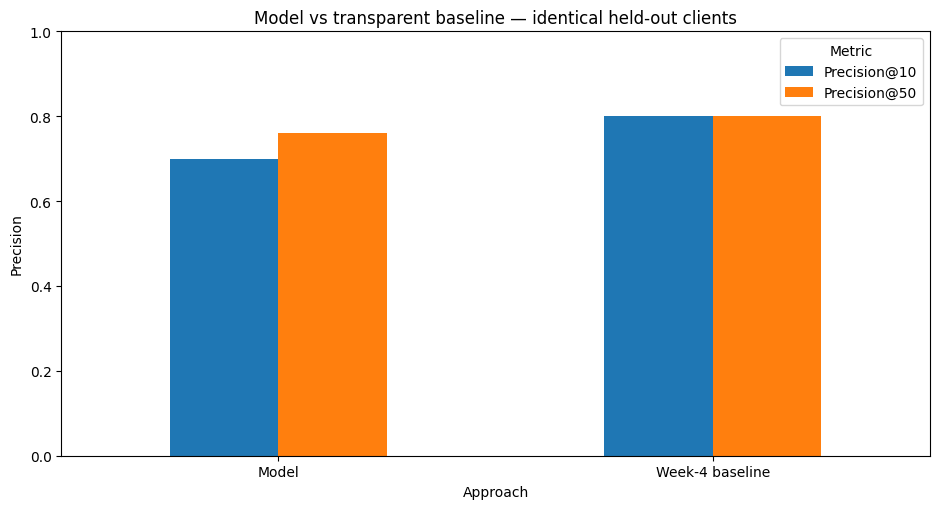

Primary result — Model P@10: 0.7000
Primary result — Baseline P@10: 0.8000
Relative P@10 difference: -12.50%


In [24]:
# Recompute evaluation in case the notebook was resumed from a partial state.
def precision_at_k(y_true, scores, k):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    k = min(k, len(y_true))
    order = np.argsort(-scores)[:k]
    return float(y_true[order].mean())

def evaluate_scores(scores):
    return {
        "Precision@10": precision_at_k(test["y"], scores, 10),
        "Precision@50": precision_at_k(test["y"], scores, 50),
        "Average Precision": float(average_precision_score(test["y"], scores)),
        "ROC-AUC": float(roc_auc_score(test["y"], scores))
    }

comparison = pd.DataFrame({
    "Model": evaluate_scores(test["model_score"]),
    "Week-4 baseline": evaluate_scores(test["baseline_score"])
}).T
comparison["Base rate"] = float(test["y"].mean())
display(comparison.round(4))

result_df = comparison[["Precision@10","Precision@50"]]
fig, ax = plt.subplots(figsize=(9.5,5.2))
result_df.plot(kind="bar", ax=ax)
ax.set_ylabel("Precision")
ax.set_xlabel("Approach")
ax.set_title("Model vs transparent baseline — identical held-out clients")
ax.set_ylim(0,1)
ax.legend(title="Metric")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("work/figures/model_vs_baseline_precision.png", dpi=220, bbox_inches="tight")
plt.show()

p10_model = float(comparison.loc["Model","Precision@10"])
p10_base = float(comparison.loc["Week-4 baseline","Precision@10"])
print(f"Primary result — Model P@10: {p10_model:.4f}")
print(f"Primary result — Baseline P@10: {p10_base:.4f}")
if p10_base:
    print(f"Relative P@10 difference: {(p10_model/p10_base-1)*100:+.2f}%")

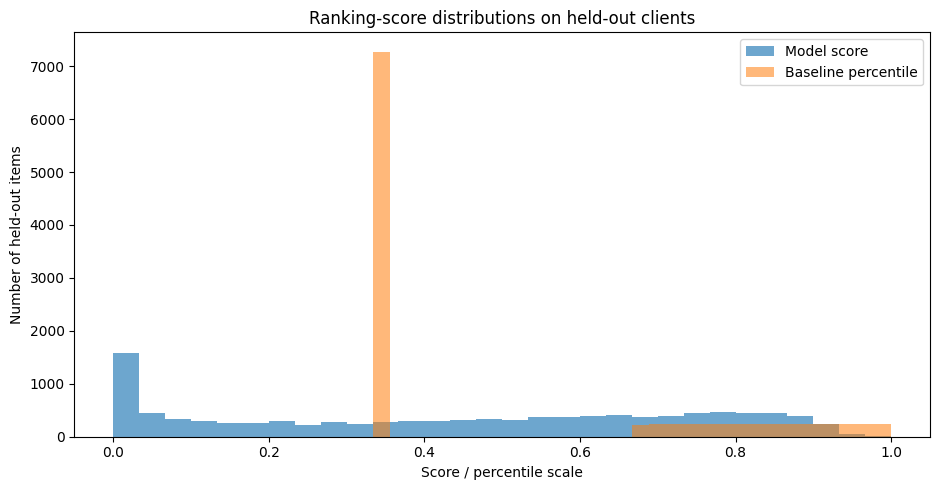

In [25]:
# Score distribution
fig, ax = plt.subplots(figsize=(9.5,5.0))
ax.hist(test["model_score"], bins=30, alpha=.65, label="Model score")
ax.hist(test["baseline_score"].rank(pct=True), bins=30, alpha=.55,
        label="Baseline percentile")
ax.set_xlabel("Score / percentile scale")
ax.set_ylabel("Number of held-out items")
ax.set_title("Ranking-score distributions on held-out clients")
ax.legend()
plt.tight_layout()
plt.savefig("work/figures/score_distributions.png", dpi=220, bbox_inches="tight")
plt.show()

## 12. Feature interpretation

The model is standardized Logistic Regression. Coefficients provide a compact descriptive view of the fitted ranking function. They are not causal effects.

,feature,coefficient
1,feb_clicks,-7.2105
3,feb_avg_position,-3.6378
0,feb_impressions,1.9209
2,feb_ctr,-0.3599


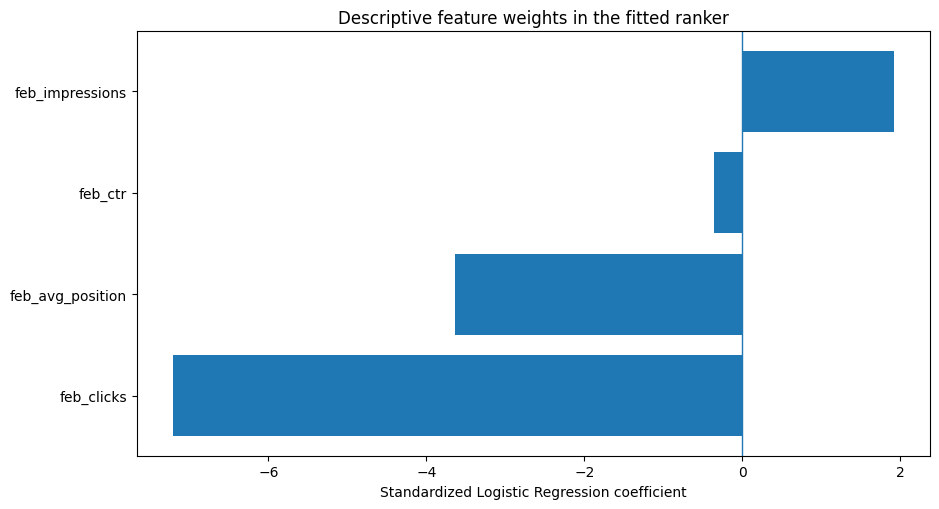

In [26]:
coef_df = pd.DataFrame({
    "feature": FEATURES,
    "coefficient": model.named_steps["logreg"].coef_[0]
})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)
display(coef_df[["feature","coefficient"]].round(4))

fig, ax = plt.subplots(figsize=(9.5,5.2))
p = coef_df.sort_values("coefficient")
ax.barh(p["feature"], p["coefficient"])
ax.axvline(0, linewidth=1)
ax.set_xlabel("Standardized Logistic Regression coefficient")
ax.set_title("Descriptive feature weights in the fitted ranker")
plt.tight_layout()
plt.savefig("work/figures/model_coefficients.png", dpi=220, bbox_inches="tight")
plt.show()

## 13. Error analysis

The paper includes false-positive and false-negative examples using pseudonymous identifiers only. This is a diagnostic, not a claim that any single page should be changed.

In [27]:
from sklearn.metrics import confusion_matrix

,Predicted 0,Predicted 1
Actual 0,5253,2473
Actual 1,478,2686


Top false positives


,client_hash_id,content_hash_id,feb_impressions,feb_ctr,feb_avg_position,future_ctr,model_score,baseline_score
1674,client_fef1a8f436438636,content_ba462518dad435fc,69134.0,0.0006,27.4775,0.0005,0.9999,0.0000
451,client_fef1a8f436438636,content_84a6bf3578312e90,79986.0,0.0009,19.7831,0.0009,0.9995,0.0000
6060,client_fef1a8f436438636,content_98302ab6c8c87253,3459.0,0.0000,0.9228,0.0019,0.9731,0.0149
9706,client_a80fca3f171ed1de,content_a6fca07f13a741ec,7750.0,0.0003,5.3785,0.0021,0.9648,0.0118
2963,client_fef1a8f436438636,content_41a735c6cf66d3c2,1136.0,0.0000,0.7086,0.0020,0.9444,0.0128
51,client_fef1a8f436438636,content_eccc82600af49b7a,1173.0,0.0000,0.8099,0.0056,0.9435,0.0129
7474,client_fef1a8f436438636,content_415ed1ccd35f2086,688.0,0.0000,0.6628,0.0028,0.9363,0.0119
2484,client_fef1a8f436438636,content_93221b793338c0fb,2174.0,0.0000,2.4825,0.0019,0.9357,0.0140
8653,client_fef1a8f436438636,content_7e24456f77660867,254.0,0.0000,0.2480,0.0028,0.9344,0.0101
5266,client_1a730cb2640a1abf,content_d8f1108dda88a3a8,9.0,0.0000,0.0000,0.0073,0.9336,0.0042


Top false negatives


,client_hash_id,content_hash_id,feb_impressions,feb_ctr,feb_avg_position,future_ctr,model_score,baseline_score
4926,client_a80fca3f171ed1de,content_cbb1fb1dff7cfda6,2.0,0.5000,3.0000,0.0000,0.0000,0.0
5310,client_1a730cb2640a1abf,content_ddc9880e631e8b1f,4.0,0.2500,6.0000,0.0000,0.0001,0.0
5257,client_1a730cb2640a1abf,content_791a6315fb70afc9,8.0,0.1250,7.3750,0.0000,0.0072,0.0
10600,client_1a730cb2640a1abf,content_e747168abe7de497,9.0,0.1111,7.8889,0.0012,0.0110,0.0
5055,client_a80fca3f171ed1de,content_8ae4f38ac16a7b0a,7.0,0.1429,1.8571,0.0000,0.0173,0.0
5919,client_fef1a8f436438636,content_419bb4d948fcb9a5,6741.0,0.0040,7.8954,0.0013,0.0209,0.0
6597,client_fef1a8f436438636,content_2aef066f1c0f0cc2,6604.0,0.0039,8.1069,0.0014,0.0237,0.0
7359,client_fef1a8f436438636,content_280d4cc796593db2,822.0,0.0146,9.7956,0.0000,0.0328,0.0
9667,client_a80fca3f171ed1de,content_110f368b229eab8d,26.0,0.0769,6.6923,0.0000,0.0490,0.0
10393,client_a80fca3f171ed1de,content_1b537d7f824df948,13.0,0.0769,7.4615,0.0000,0.0493,0.0


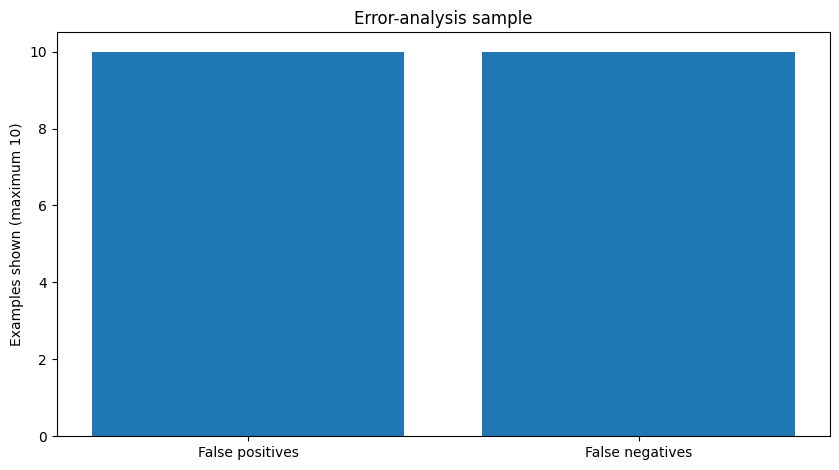

In [28]:
test["model_pred"] = (test["model_score"] >= 0.5).astype(int)
cm = confusion_matrix(test["y"], test["model_pred"], labels=[0,1])
cm_df = pd.DataFrame(cm, index=["Actual 0","Actual 1"],
                     columns=["Predicted 0","Predicted 1"])
display(cm_df)

error_cols = [
    "client_hash_id","content_hash_id","feb_impressions",
    "feb_ctr","feb_avg_position","future_ctr",
    "model_score","baseline_score"
]
false_pos = test[(test.model_pred==1)&(test.y==0)].sort_values(
    "model_score", ascending=False).head(10)
false_neg = test[(test.model_pred==0)&(test.y==1)].sort_values(
    "model_score", ascending=True).head(10)

print("Top false positives")
display(false_pos[error_cols].round(4))
print("Top false negatives")
display(false_neg[error_cols].round(4))

fig, ax = plt.subplots(figsize=(8.5,4.8))
ax.bar(["False positives","False negatives"],
       [len(false_pos),len(false_neg)])
ax.set_ylabel("Examples shown (maximum 10)")
ax.set_title("Error-analysis sample")
plt.tight_layout()
plt.savefig("work/figures/error_analysis.png", dpi=220, bbox_inches="tight")
plt.show()

## 14. Content age / refresh context

Content age is **not** used as a final model feature. It is included only as a descriptive lens for the action playbook. Patterns must be described as observed/directional; this analysis does not establish that age causes CTR decline or that refreshing content causes improvement.

,age_band,items,median_ctr,median_impressions
0,0-90d,5916,0.00000,216.0
1,91-180d,1272,0.00000,350.5
2,181-365d,3658,0.00145,657.5
3,1-2y,44,0.00698,98.5


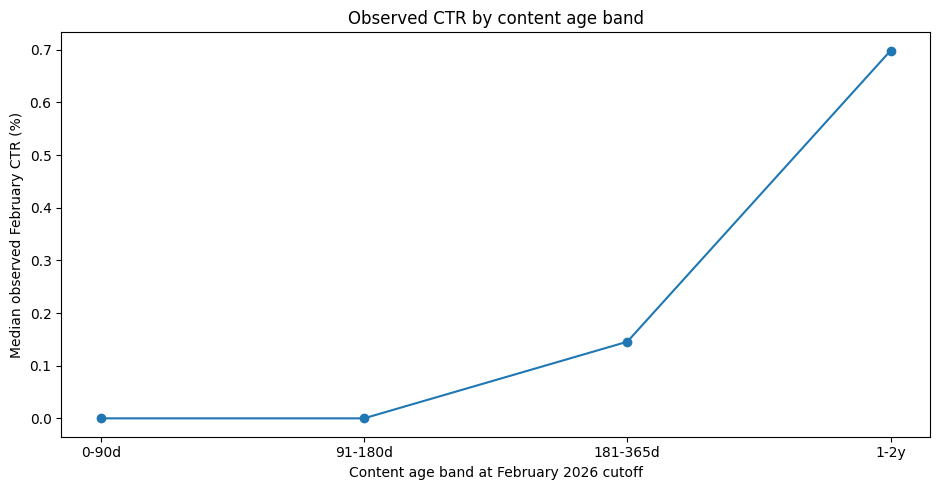

In [33]:
# Content age / refresh context

# FIX: use the actual dim_content parquet path here.
# The previous path with "/dim_content/*.parquet" does not exist.
DIM = "hf://datasets/FlyRank/internship-warehouse/dim_content.parquet"

age_sql = f"""
SELECT
    content_hash_id,
    CAST(content_created_date AS DATE) AS content_created_date
FROM read_parquet('{DIM}')
WHERE content_created_date IS NOT NULL
"""

content_dates = con.sql(age_sql).df()

age_view = test.merge(
    content_dates,
    on="content_hash_id",
    how="left",
    validate="many_to_one"
)

age_view["content_age_days_feb"] = (
    pd.Timestamp("2026-02-28")
    - pd.to_datetime(age_view["content_created_date"])
).dt.days

age_view = age_view[
    age_view["content_age_days_feb"].ge(0)
].copy()

age_view["age_band"] = pd.cut(
    age_view["content_age_days_feb"],
    bins=[-1, 90, 180, 365, 730, np.inf],
    labels=["0-90d", "91-180d", "181-365d", "1-2y", "2y+"]
)

age_summary = (
    age_view
    .groupby("age_band", observed=True)
    .agg(
        items=("content_hash_id", "size"),
        median_ctr=("feb_ctr", "median"),
        median_impressions=("feb_impressions", "median")
    )
    .reset_index()
)

display(age_summary.round(5))

fig, ax = plt.subplots(figsize=(9.5, 5.0))

p = age_summary.dropna(subset=["median_ctr"])

ax.plot(
    p["age_band"].astype(str),
    p["median_ctr"] * 100,
    marker="o"
)

ax.set_xlabel("Content age band at February 2026 cutoff")
ax.set_ylabel("Median observed February CTR (%)")
ax.set_title("Observed CTR by content age band")

plt.tight_layout()

plt.savefig(
    "work/figures/ctr_by_content_age.png",
    dpi=220,
    bbox_inches="tight"
)

plt.show()

## 15. Ranked action playbook

The model output is a **decision-support queue**. It does not automatically publish, refresh, rewrite, or alter content.

In [34]:
queue = test.copy()
queue["priority_score"] = queue["model_score"]
queue["reason_code"] = np.where(
    queue["ctr_gap_pp"] > 0,
    "below_position_ctr",
    "no_positive_ctr_gap"
)

q90 = queue["priority_score"].quantile(.90)
q50 = queue["priority_score"].quantile(.50)

queue["action"] = np.select(
    [
        queue["priority_score"].ge(q90) & queue["feb_impressions"].ge(100),
        queue["priority_score"].ge(q50)
    ],
    [
        "Prioritize CTR review",
        "Review if capacity allows"
    ],
    default="Monitor / do not prioritize"
)

queue = queue.sort_values(
    ["priority_score","feb_impressions"],
    ascending=[False,False]
)

queue_cols = [
    "client_hash_id","content_hash_id","priority_score",
    "reason_code","action","feb_impressions",
    "feb_ctr","feb_avg_position"
]
display(queue[queue_cols].head(20).round(4))

action_summary = (
    queue.groupby("action", observed=True)
    .agg(
        items=("content_hash_id","size"),
        median_score=("priority_score","median"),
        median_impressions=("feb_impressions","median")
    )
    .reset_index()
)
display(action_summary.round(4))

queue[queue_cols].to_csv(
    "work/outputs/content_action_playbook_queue.csv", index=False
)

,client_hash_id,content_hash_id,priority_score,reason_code,action,feb_impressions,feb_ctr,feb_avg_position
3323,client_b10cb2997d0c7c86,content_4257d1459eb1fdd1,1.0000,below_position_ctr,Prioritize CTR review,32934.0,0.0001,6.7480
5801,client_fef1a8f436438636,content_fc0d3723ce5a9bba,1.0000,below_position_ctr,Prioritize CTR review,38452.0,0.0004,7.0654
1674,client_fef1a8f436438636,content_ba462518dad435fc,0.9999,no_positive_ctr_gap,Prioritize CTR review,69134.0,0.0006,27.4775
451,client_fef1a8f436438636,content_84a6bf3578312e90,0.9995,no_positive_ctr_gap,Prioritize CTR review,79986.0,0.0009,19.7831
414,client_fef1a8f436438636,content_1ba7817ad0539568,0.9943,below_position_ctr,Prioritize CTR review,19527.0,0.0006,5.1035
5537,client_fef1a8f436438636,content_5cc6fa5852bf25f1,0.9903,below_position_ctr,Prioritize CTR review,6314.0,0.0000,0.8337
8989,client_65de48885f4ef01b,content_62673eea26c31c17,0.9874,below_position_ctr,Prioritize CTR review,45107.0,0.0012,5.4943
805,client_fef1a8f436438636,content_f59ebede9f977e3b,0.9811,below_position_ctr,Prioritize CTR review,17703.0,0.0006,8.6789
727,client_fef1a8f436438636,content_e5f3b7212872fffe,0.9753,below_position_ctr,Prioritize CTR review,11269.0,0.0009,1.8266
6060,client_fef1a8f436438636,content_98302ab6c8c87253,0.9731,below_position_ctr,Prioritize CTR review,3459.0,0.0000,0.9228


,action,items,median_score,median_impressions
0,Monitor / do not prioritize,5445,0.1391,445.0
1,Prioritize CTR review,807,0.8779,455.0
2,Review if capacity allows,4638,0.6797,241.5


### Human-review rules and no-go decisions

**Review before action**

- verify measured impression volume;
- inspect position context;
- use whatever page/query context is legitimately available to the reviewer;
- check recent edits and seasonality;
- check business importance and conversion context;
- investigate measurement gaps or abrupt tracking changes.

**No-go**

- do not auto-publish content changes from the score;
- do not claim a refresh will cause a CTR increase;
- do not expose client names, domains, URLs, raw queries, titles, or restricted search text;
- do not treat pseudonymous IDs as predictive features.

## 16. Research interpretation

### Main result

The primary conclusion is conditional on the observed held-out split: compare the model and baseline **only through the same validation set and the same target definition**. A model that wins this comparison provides evidence that the learned ranking function contains additional predictive signal under this setup; a small or negative gain is equally valid evidence that the transparent rule is competitive.

### Operational interpretation

The safest use of the result is to improve the order in which humans inspect pages. The score should be treated as prioritization evidence, not as an autonomous content recommendation engine.

### Monitoring and retraining triggers

A production-like implementation should monitor:

1. Precision@10 drift;
2. feature distribution drift;
3. target/base-rate drift;
4. missingness changes;
5. position-tier mix changes;
6. reviewer acceptance or override rates.

Retraining should be considered only after enough new outcome data accumulates to support a fresh leakage-safe evaluation.

## 17. Limitations

1. The outcome is a benchmark-relative proxy, not a direct intervention-success label.
2. The study uses one February → March observation window.
3. Client-grouped validation improves the honesty of the split but does not prove long-term generalization.
4. CTR is observational and influenced by position, query mix, seasonality, brand demand, snippets, and other factors not modeled here.
5. Low-volume metrics can be noisy; the March threshold of 100 impressions reduces but does not eliminate this issue.
6. Content age analysis is descriptive and cannot establish causality.
7. The fitted coefficients are model weights, not causal effects.
8. A single held-out split is useful but should be supplemented by repeated group splits or later time windows before production use.

## 18. Reproducibility and public-safety

The notebook regenerates all major tables and figures from the warehouse using the existing FlyRank internship repository workflow. The Hugging Face token is read from Colab Secrets as `HF_TOKEN`; it is never embedded in the notebook.

The public paper contains only aggregated, pseudonymous, or methodological information. Client names, domains, URLs, raw queries, titles, and restricted search text are not published.

**Repository:** `https://github.com/Samarjamal326/Flyrank`

**Data credit:** Built on the FlyRank ML Internship dataset.

In [36]:
# 19. Build the detailed static research paper
from pathlib import Path
import base64, json

def img_data(path):
    return "data:image/png;base64," + base64.b64encode(
        Path(path).read_bytes()
    ).decode("ascii")

def html_table(df, index=False):
    return df.to_html(
        index=index, classes="data-table", border=0,
        float_format=lambda x: f"{x:.4f}"
    )

model_p10 = float(comparison.loc["Model","Precision@10"])
base_p10 = float(comparison.loc["Week-4 baseline","Precision@10"])
model_p50 = float(comparison.loc["Model","Precision@50"])
base_p50 = float(comparison.loc["Week-4 baseline","Precision@50"])
model_ap = float(comparison.loc["Model","Average Precision"])
base_ap = float(comparison.loc["Week-4 baseline","Average Precision"])
model_auc = float(comparison.loc["Model","ROC-AUC"])
base_auc = float(comparison.loc["Week-4 baseline","ROC-AUC"])
p10_lift = ((model_p10 / base_p10) - 1) if base_p10 else float("nan")

metrics = {
    "eligible_rows": int(len(data)),
    "train_rows": int(len(train)),
    "test_rows": int(len(test)),
    "train_clients": int(train.client_hash_id.nunique()),
    "test_clients": int(test.client_hash_id.nunique()),
    "base_rate": float(test["y"].mean()),
    "model_precision_at_10": model_p10,
    "baseline_precision_at_10": base_p10,
    "model_precision_at_50": model_p50,
    "baseline_precision_at_50": base_p50,
    "model_average_precision": model_ap,
    "baseline_average_precision": base_ap,
    "model_roc_auc": model_auc,
    "baseline_roc_auc": base_auc,
    "relative_precision_at_10_difference": p10_lift,
}
Path("work/outputs/capstone_metrics.json").write_text(
    json.dumps(metrics, indent=2), encoding="utf-8"
)
comparison.to_csv("work/outputs/model_vs_baseline_metrics.csv")
coef_df[["feature","coefficient"]].to_csv(
    "work/outputs/model_coefficients.csv", index=False
)
tier_summary.reset_index().to_csv(
    "work/outputs/position_tier_summary.csv", index=False
)
age_summary.to_csv("work/outputs/content_age_summary.csv", index=False)

abstract = (
    "This study asks whether a leakage-safe model can prioritize content items "
    "for search-engagement review better than a transparent rule. "
    "Using February 2026 decision features and a March 2026 benchmark-relative "
    "CTR outcome from the FlyRank internship warehouse, the analysis trains an "
    "interpretable Logistic Regression and compares it with the Week-4 baseline "
    "on the same client-held-out test set. "
    f"The model's observed Precision@10 was {model_p10:.3f}, compared with "
    f"{base_p10:.3f} for the baseline. "
    "These results are measured on one validation slice and should be interpreted "
    "as directional decision-support evidence rather than proof that an "
    "intervention causes higher CTR. "
    "The resulting playbook ranks pages for human review while explicitly "
    "avoiding autonomous publishing or causal refresh claims."
)

data_contract = pd.DataFrame({
    "Component": [
        "Unit","Decision window","Outcome window","GSC inclusion",
        "Outcome threshold","Primary metric","Split","Model features",
        "Excluded from features"
    ],
    "Definition": [
        "One pseudonymized client × content item",
        "February 2026","March 2026",
        "gsc_data_available IS TRUE",
        "At least 100 March impressions",
        "Precision@10","80/20 client-grouped holdout",
        "February impressions, clicks, CTR, impression-weighted position",
        "March outcomes, trend-derived fields, IDs"
    ]
})

html_doc = f"""<!doctype html>
<html>
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>CTR / Engagement Opportunity Scoring — FlyRank ML Capstone</title>
<style>
body{{margin:0;background:#f3f5f7;color:#17202a;font-family:Inter,Segoe UI,Arial,sans-serif;line-height:1.68}}
.wrap{{max-width:1160px;margin:auto;padding:36px 22px 90px}}
.hero{{background:#101820;color:#fff;border-radius:24px;padding:52px 54px;margin-bottom:24px}}
.eyebrow{{text-transform:uppercase;letter-spacing:.16em;font-size:12px;opacity:.72;font-weight:700}}
h1{{font-size:46px;line-height:1.08;margin:12px 0 14px}}
h2{{font-size:28px;line-height:1.2;margin:42px 0 16px}}
h3{{font-size:19px;margin:28px 0 8px}}
.lead{{font-size:19px;color:#dce3e8;max-width:920px}}
.card{{background:#fff;border:1px solid #e1e6ea;border-radius:18px;padding:28px 30px;margin:18px 0;box-shadow:0 8px 28px rgba(20,30,40,.045)}}
.grid{{display:grid;grid-template-columns:repeat(4,1fr);gap:14px}}
.stat{{background:#f7f9fa;border-radius:14px;padding:17px}}
.stat span{{display:block;color:#66737d;font-size:13px}}
.stat b{{display:block;font-size:29px;margin-top:4px}}
.data-table{{border-collapse:collapse;width:100%;font-size:14px;margin:10px 0}}
.data-table th,.data-table td{{padding:10px 11px;border-bottom:1px solid #e5e9ed;text-align:left;vertical-align:top}}
.data-table th{{background:#f6f8f9;font-weight:700}}
.figure{{width:100%;border-radius:12px;border:1px solid #e1e6ea;margin:12px 0 4px}}
.caption{{font-size:13px;color:#68747d;margin-bottom:18px}}
.callout{{border-left:4px solid #17202a;background:#f6f8f9;padding:15px 18px;border-radius:8px;margin:16px 0}}
.kicker{{font-weight:700;color:#38444e}}
a{{color:#155eef;text-decoration:none}}
code{{background:#eef2f5;padding:2px 5px;border-radius:4px}}
li{{margin:6px 0}}
.small{{font-size:13px;color:#66737d}}
@media(max-width:820px){{h1{{font-size:35px}}.grid{{grid-template-columns:repeat(2,1fr)}}.hero{{padding:34px 26px}}}}
</style>
</head>
<body><div class="wrap">

<section class="hero">
<div class="eyebrow">FlyRank ML Internship · ML-11 Capstone</div>
<h1>CTR / Engagement Opportunity Scoring</h1>
<p class="lead">Can a leakage-safe machine-learning ranker prioritize content items for search-engagement review better than a transparent rule?</p>
</section>

<section class="card">
<h2 style="margin-top:0">Abstract</h2>
<p>{abstract}</p>
</section>

<section class="card">
<h2 style="margin-top:0">Study at a glance</h2>
<div class="grid">
<div class="stat"><span>Eligible client-content rows</span><b>{len(data):,}</b></div>
<div class="stat"><span>Train clients</span><b>{train.client_hash_id.nunique():,}</b></div>
<div class="stat"><span>Held-out clients</span><b>{test.client_hash_id.nunique():,}</b></div>
<div class="stat"><span>Model Precision@10</span><b>{model_p10:.3f}</b></div>
</div>
</section>

<section class="card">
<h2>1. Introduction and problem statement</h2>
<p>Content teams can have more pages worth investigating than they can manually review. The practical objective is therefore a ranking problem: place pages most likely to merit CTR/engagement review near the top of a finite review queue.</p>
<div class="callout"><b>Research question:</b> Can February search-performance signals rank March benchmark-relative CTR-risk pages better than the Week-4 transparent baseline on clients that were not used for training?</div>
<p><b>Primary decision metric:</b> Precision@10, because the intended operational use is a small top-of-queue review list.</p>
</section>

<section class="card">
<h2>2. Data and architecture</h2>
<p>The warehouse is treated as the source of truth. Daily performance is aggregated into a February decision window and a March outcome window. The modeling unit is one pseudonymized client × content item. The content dimension is used only for the descriptive content-age analysis.</p>
<img class="figure" src="{img_data('work/figures/architecture_pipeline.png')}">
<div class="caption">Figure 1. End-to-end warehouse → feature → model → decision architecture.</div>
<h3>Data contract</h3>
{html_table(data_contract)}
<p class="small">Public outputs exclude client names, domains, URLs, raw queries, titles, and restricted search text.</p>
</section>

<section class="card">
<h2>3. Methodology</h2>
<h3>Features</h3>
<p><code>feb_impressions</code>, <code>feb_clicks</code>, <code>feb_ctr</code>, and impression-weighted <code>feb_avg_position</code>.</p>
<h3>Proxy target</h3>
<p>For each position tier, the training clients define a February median CTR benchmark. A content item is positive when March CTR falls below that frozen benchmark. This is a benchmark-relative risk proxy, not a direct intervention-success label.</p>
<h3>Transparent baseline</h3>
<p><code>max(training_tier_median_ctr − feb_ctr, 0) × log(1 + feb_impressions)</code>. The rule is deliberately transparent: a larger measured CTR gap and stronger volume increase priority.</p>
<h3>Validation</h3>
<p>An 80/20 split is performed by <code>client_hash_id</code>. The position-tier benchmark is learned from training clients only and then frozen for held-out clients. March outcomes and label-derived fields are excluded from model features.</p>
<img class="figure" src="{img_data('work/figures/methodology_validation.png')}">
<div class="caption">Figure 2. Leakage-safe validation design.</div>
</section>

<section class="card">
<h2>4. Data and split receipt</h2>
{html_table(data_receipt)}
</section>

<section class="card">
<h2>5. Exploratory results: CTR by position tier</h2>
<p>Position-tier results provide descriptive context for the benchmark-relative target. They should be read as observed associations, not causal effects.</p>
{html_table(tier_summary.reset_index())}
<img class="figure" src="{img_data('work/figures/ctr_by_position_tier.png')}">
<div class="caption">Figure 3. Observed weighted February CTR by position tier on held-out clients.</div>
</section>

<section class="card">
<h2>6. Model vs baseline results</h2>
<div class="grid">
<div class="stat"><span>Model P@10</span><b>{model_p10:.3f}</b></div>
<div class="stat"><span>Baseline P@10</span><b>{base_p10:.3f}</b></div>
<div class="stat"><span>Model Average Precision</span><b>{model_ap:.3f}</b></div>
<div class="stat"><span>Model ROC-AUC</span><b>{model_auc:.3f}</b></div>
</div>
<p>On the same held-out clients, the model's Precision@10 was <b>{model_p10:.3f}</b> versus <b>{base_p10:.3f}</b> for the baseline. The relative P@10 difference was <b>{p10_lift*100:.2f}%</b> when the baseline was non-zero.</p>
{html_table(comparison.reset_index().rename(columns={"index": "Approach"}))}
<img class="figure" src="{img_data('work/figures/model_vs_baseline_precision.png')}">
<div class="caption">Figure 4. Primary model-vs-baseline comparison on the identical client-held-out test set.</div>
<img class="figure" src="{img_data('work/figures/score_distributions.png')}">
<div class="caption">Figure 5. Distribution of ranking scores on held-out clients.</div>
<div class="callout"><b>Interpretation:</b> this is an observed validation comparison, not a production guarantee and not causal evidence that changing selected pages will improve CTR.</div>
</section>

<section class="card">
<h2>7. Feature interpretation and error analysis</h2>
{html_table(coef_df[["feature","coefficient"]])}
<img class="figure" src="{img_data('work/figures/model_coefficients.png')}">
<div class="caption">Figure 6. Descriptive standardized coefficients of the fitted Logistic Regression.</div>
<img class="figure" src="{img_data('work/figures/error_analysis.png')}">
<div class="caption">Figure 7. Error-analysis sample. Detailed pseudonymous examples are generated in the notebook.</div>
</section>

<section class="card">
<h2>8. Content age / refresh context</h2>
<p>Content age is not used as a final model feature. It is a descriptive lens for interpreting the review queue. The observed pattern does not establish that age causes CTR decline or that refreshing content causes improvement.</p>
{html_table(age_summary)}
<img class="figure" src="{img_data('work/figures/ctr_by_content_age.png')}">
<div class="caption">Figure 8. Observed median February CTR by content-age band.</div>
</section>

<section class="card">
<h2>9. Ranked action playbook</h2>
<ol>
<li><b>Prioritize CTR review</b> for high-scoring items with sufficient measured volume.</li>
<li><b>Review if capacity allows</b> for moderate-scoring items with adequate evidence.</li>
<li><b>Monitor / do not prioritize</b> weak or low-evidence items.</li>
</ol>
{html_table(action_summary)}
<div class="callout"><b>Human review rule:</b> verify measured volume, position context, available page/query context, recent edits, seasonality, business importance, and measurement gaps before acting.</div>
<h3>No-go decisions</h3>
<ul>
<li>Do not auto-publish content changes from the score.</li>
<li>Do not claim a refresh will cause a CTR increase.</li>
<li>Do not publish client names, domains, URLs, raw queries, titles, or restricted search text.</li>
<li>Do not treat pseudonymous IDs as predictive features.</li>
</ul>
</section>

<section class="card">
<h2>10. Limitations and honest framing</h2>
<h3>What the evidence supports</h3>
<ul>
<li>The learned ranker can be compared with the transparent baseline under the stated held-out validation design.</li>
<li>Client-grouped validation prevents the same client from appearing in both train and test.</li>
<li>The resulting score can support a human review queue.</li>
</ul>
<h3>What the evidence does not support</h3>
<ul>
<li>No causal claim that refreshing content increases CTR.</li>
<li>No causal claim that content age causes performance changes.</li>
<li>No long-term or production generalization guarantee from one February → March window.</li>
<li>No claim that the benchmark-relative proxy is equivalent to intervention success.</li>
</ul>
<div class="callout"><b>Defensible claim:</b> The model provides a leakage-safe ranking of pages for CTR/engagement review; the validation result indicates whether this ranking is more precise than the transparent baseline on the held-out clients used in this study.</div>
</section>

<section class="card">
<h2>11. Monitoring and future validation</h2>
<p>A production-like implementation should monitor Precision@10 drift, feature distribution drift, target/base-rate drift, missingness changes, position-tier mix, and reviewer overrides. Before production use, the methodology should be repeated across additional time windows or repeated client-grouped splits.</p>
</section>

<section class="card">
<h2>12. Reproducibility and data credit</h2>
<p>The weekly notebooks and capstone live under <code>work/notebooks/</code> in the repository. This notebook regenerates the research tables, figures, metrics, action queue, and static paper.</p>
<p><b>Repository:</b> <a href="https://github.com/Samarjamal326/Flyrank">github.com/Samarjamal326/Flyrank</a></p>
<p><b>Data credit:</b> Built on the FlyRank ML Internship dataset. <a href="https://flyrank.ai">FlyRank</a></p>
<p><b>Expected GitHub Pages URL:</b> https://samarjamal326.github.io/Flyrank/</p>
</section>

</div></body></html>"""

Path("docs/index.html").write_text(html_doc, encoding="utf-8")
Path("work/paper/index.html").write_text(html_doc, encoding="utf-8")
Path("submission/paper_url.txt").write_text(
    "https://samarjamal326.github.io/Flyrank/\n", encoding="utf-8"
)

print("Detailed paper exported to:")
print("  docs/index.html")
print("  work/paper/index.html")
print("Metrics:", json.dumps(metrics, indent=2))

Detailed paper exported to:
  docs/index.html
  work/paper/index.html
Metrics: {
  "eligible_rows": 86560,
  "train_rows": 75670,
  "test_rows": 10890,
  "train_clients": 29,
  "test_clients": 8,
  "base_rate": 0.29054178145087234,
  "model_precision_at_10": 0.7,
  "baseline_precision_at_10": 0.8,
  "model_precision_at_50": 0.76,
  "baseline_precision_at_50": 0.8,
  "model_average_precision": 0.5705530944912487,
  "baseline_average_precision": 0.5476148963455494,
  "model_roc_auc": 0.8193011889844102,
  "baseline_roc_auc": 0.7686810515202578,
  "relative_precision_at_10_difference": -0.1250000000000001
}


## 20. Final submission self-check

- [ ] Five-sentence abstract: question → method → result → interpretation.
- [ ] Detailed problem statement and contribution.
- [ ] Data contract and dataset receipt.
- [ ] Architecture diagram.
- [ ] Leakage-safe methodology/validation diagram.
- [ ] Multiple results tables.
- [ ] Multiple graphs, including model vs baseline.
- [ ] Feature interpretation.
- [ ] Error analysis.
- [ ] Content-age descriptive analysis.
- [ ] Ranked action playbook.
- [ ] Limitations and honest claim rewrite.
- [ ] Monitoring/retraining guidance.
- [ ] Public-safety pass.
- [ ] `docs/index.html` exists for GitHub Pages.
- [ ] `submission/paper_url.txt` contains exactly one URL.